# Personal Income & Its Disposition — m/m & y/y Changes and Contributions
### BEA NIPA Table 2.6 (Personal Income and Its Disposition, Monthly)

Pulls **BEA NIPA Table 2.6** (`T20600`) via the BEA Data API and decomposes month-over-month (m/m)
and year-over-year (y/y) growth in **Personal Income** and **Disposable Personal Income** into
additive contributions.

**Decomposition.** Table 2.6 is current-dollar (nominal), seasonally adjusted at annual rates, so
the components sum exactly and contributions are additive:

- **Personal income** = Wages & salaries + Non-wage market income + Transfer receipts − Contributions for govt social insurance
- **Disposable income** = Personal income − Personal current taxes
- *Non-wage market income* = supplements to wages + proprietors' + rental + asset income (interest & dividends).

Deduction lines (social-insurance contributions, personal current taxes) enter with a **negative
sign**, so they appear as downward bars / negative contributions.

For any line *i* measured against a total *T*:
- m/m contribution (pp):  $c^{mm}_i = (X_{i,t}-X_{i,t-1})/T_{t-1}\times100$
- y/y contribution (pp):  $c^{yy}_i = (X_{i,t}-X_{i,t-12})/T_{t-12}\times100$

*Source:* U.S. Bureau of Economic Analysis, NIPA Table 2.6 (current \$, SAAR, millions), via the
[BEA Data API](https://apps.bea.gov/api/).

## 0. Imports & configuration

In [1]:
import json, datetime, urllib.request, urllib.parse
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from IPython.display import display

API_KEY    = "FD4E7F46-5D89-4CA8-BE48-4F5997F83B3B"   # BEA Data API key
TABLE      = "T20600"        # NIPA Table 2.6 - Personal Income and Its Disposition, Monthly
FREQ       = "M"
START_YEAR = 2014            # enough history for y/y + trend
END_YEAR   = datetime.date.today().year
N_MONTHS   = 12              # trend window shown in the charts

OUTDIR = Path("outputs"); OUTDIR.mkdir(exist_ok=True)

## 1. Fetch & parse Table 2.6

In [2]:
def fetch_bea_nipa(table, freq, years, api_key=API_KEY):
    """Return the list of observation records for a NIPA table from the BEA API."""
    params = {"UserID": api_key, "method": "GetData", "datasetname": "NIPA",
              "TableName": table, "Frequency": freq,
              "Year": ",".join(map(str, years)), "ResultFormat": "json"}
    url = "https://apps.bea.gov/api/data/?" + urllib.parse.urlencode(params)
    with urllib.request.urlopen(url, timeout=60) as resp:
        payload = json.loads(resp.read().decode("utf-8"))
    results = payload["BEAAPI"]["Results"]
    if isinstance(results, list):
        results = results[0]
    return results["Data"]


def parse_period(tp):                       # '2026M04' -> Timestamp('2026-04-01')
    y, m = tp.split("M")
    return pd.Timestamp(int(y), int(m), 1)


years   = list(range(START_YEAR, END_YEAR + 1))
records = fetch_bea_nipa(TABLE, FREQ, years)

raw = pd.DataFrame(records)
raw["value"] = pd.to_numeric(raw["DataValue"].astype(str).str.replace(",", "", regex=False),
                             errors="coerce")
raw["date"]  = raw["TimePeriod"].map(parse_period)
levels = (raw.pivot_table(index="date", columns="SeriesCode", values="value", aggfunc="first")
          .sort_index())
print(f"Fetched {len(records):,} obs - {levels.index.min():%Y-%m} to {levels.index.max():%Y-%m}")

Fetched 6,364 obs - 2014-01 to 2026-04


## 2. Components & contributions

Build signed component levels (deductions enter **negative**) and compute, for the latest data,
each component's own m/m & y/y % change plus its contribution (pp) to **Personal income** and to
**Disposable income**. Additivity is asserted so the contributions reconcile exactly.

In [3]:
# signed component levels: deductions enter NEGATIVE so components sum to their totals
comp = pd.DataFrame({
    "Wages and salaries":              levels["A034RC"],
    "Non-wage market income":          levels[["A038RC", "A041RC", "A048RC", "W210RC"]].sum(axis=1),
    "Transfer payment receipts":       levels["A577RC"],
    "Less: social insurance contrib.": -levels["A061RC"],
    "Less: personal current taxes":    -levels["W055RC"],
})
PI  = levels["A065RC"]      # Personal income
DPI = levels["A067RC"]      # Disposable personal income

PI_COMPS  = ["Wages and salaries", "Non-wage market income",
             "Transfer payment receipts", "Less: social insurance contrib."]
DPI_COMPS = PI_COMPS + ["Less: personal current taxes"]

# own percent changes, and contributions (pp) to each total
mm = comp.pct_change(1,  fill_method=None) * 100
yy = comp.pct_change(12, fill_method=None) * 100
cmm_pi  = comp[PI_COMPS].diff(1).div(PI.shift(1),   axis=0) * 100
cyy_pi  = comp[PI_COMPS].diff(12).div(PI.shift(12), axis=0) * 100
cmm_dpi = comp[DPI_COMPS].diff(1).div(DPI.shift(1),   axis=0) * 100
cyy_dpi = comp[DPI_COMPS].diff(12).div(DPI.shift(12), axis=0) * 100

pi_mm,  pi_yy  = PI.pct_change(1)  * 100, PI.pct_change(12)  * 100
dpi_mm, dpi_yy = DPI.pct_change(1) * 100, DPI.pct_change(12) * 100

latest = levels.index.max()
assert np.allclose(comp[PI_COMPS].sum(axis=1),  PI,  rtol=1e-4), "PI components do not sum to PI"
assert np.allclose(comp[DPI_COMPS].sum(axis=1), DPI, rtol=1e-4), "DPI components do not sum to DPI"
print(f"Latest month: {latest:%B %Y}")
print(f"Personal income   m/m = {pi_mm.loc[latest]:+.3f}%   (contribs sum = {cmm_pi.loc[latest].sum():+.3f} pp)")
print(f"Disposable income m/m = {dpi_mm.loc[latest]:+.3f}%   (contribs sum = {cmm_dpi.loc[latest].sum():+.3f} pp)")
print("Additivity checks passed.")

Latest month: April 2026
Personal income   m/m = -0.000%   (contribs sum = -0.000 pp)
Disposable income m/m = -0.085%   (contribs sum = -0.085 pp)
Additivity checks passed.


## 3. Chart — Personal income momentum (m/m vs 3-month annualized rate)

Bars = monthly % change (left axis, red when negative); line = 3-month annualized rate
$(X_t/X_{t-3})^4-1$ (right axis). Window = last `N_MONTHS` months.

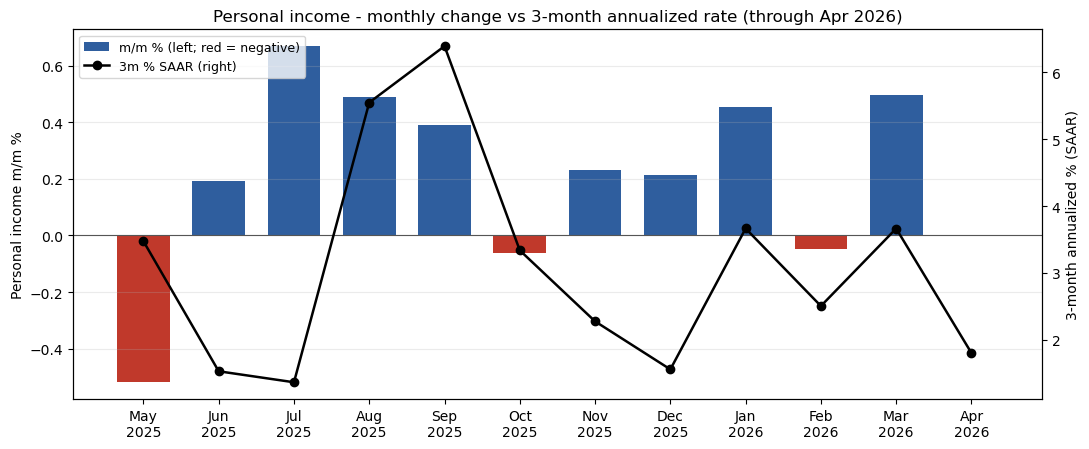

In [4]:
recent = levels.index[-N_MONTHS:]
x = np.arange(len(recent))
pi_saar = (PI / PI.shift(3)) ** 4 * 100 - 100          # 3-month annualized rate (SAAR)

fig, ax1 = plt.subplots(figsize=(11, 4.6))
ax1.bar(x, pi_mm.loc[recent], width=0.7,
        color=["#2f5e9e" if v >= 0 else "#c0392b" for v in pi_mm.loc[recent]])
ax1.axhline(0, color="#555", lw=0.8)
ax1.set_ylabel("Personal income m/m %")

ax2 = ax1.twinx()
ax2.plot(x, pi_saar.loc[recent].to_numpy(), "o-", color="black", lw=1.8)
ax2.set_ylabel("3-month annualized % (SAAR)")

ax1.set_xticks(x); ax1.set_xticklabels([d.strftime("%b\n%Y") for d in recent])
ax1.set_title(f"Personal income - monthly change vs 3-month annualized rate (through {recent[-1]:%b %Y})")
ax1.legend(handles=[Patch(facecolor="#2f5e9e", label="m/m % (left; red = negative)"),
                    Line2D([0], [0], color="black", marker="o", lw=1.8, label="3m % SAAR (right)")],
           loc="upper left", fontsize=9)
ax1.grid(axis="y", alpha=0.25)
fig.tight_layout()
fig.savefig(OUTDIR / "pi_2_6_momentum.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Chart — Personal income contributions

Stacked bars = each component's contribution (pp) to **Personal income** m/m growth; black line =
Personal income m/m %. The deduction (social insurance) shows as a downward segment.

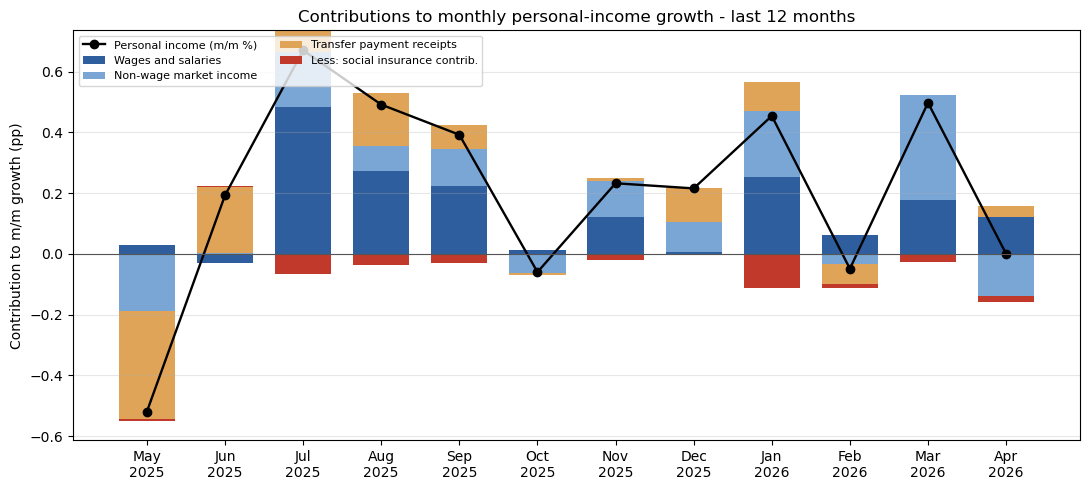

In [5]:
COLORS = {"Wages and salaries": "#2f5e9e", "Non-wage market income": "#7aa6d6",
          "Transfer payment receipts": "#e0a458",
          "Less: social insurance contrib.": "#c0392b",
          "Less: personal current taxes": "#8e44ad"}


def contrib_chart(cdf, total_mm, comp_list, total_label, title, fname):
    x = np.arange(len(recent))
    pos = np.zeros(len(recent)); neg = np.zeros(len(recent))
    fig, ax = plt.subplots(figsize=(11, 5))
    for c in comp_list:
        v = cdf.loc[recent, c].to_numpy()
        p, n = np.clip(v, 0, None), np.clip(v, None, 0)
        ax.bar(x, p, bottom=pos, color=COLORS[c], width=0.72, label=c)
        ax.bar(x, n, bottom=neg, color=COLORS[c], width=0.72)
        pos += p; neg += n
    ax.plot(x, total_mm.loc[recent].to_numpy(), "o-", color="black", lw=1.7,
            label=f"{total_label} (m/m %)")
    ax.axhline(0, color="#555", lw=0.8)
    ax.set_xticks(x); ax.set_xticklabels([d.strftime("%b\n%Y") for d in recent])
    ax.set_ylabel("Contribution to m/m growth (pp)")
    ax.set_title(title)
    ax.legend(loc="upper left", fontsize=8, ncol=2)
    ax.grid(axis="y", alpha=0.3)
    fig.tight_layout()
    fig.savefig(OUTDIR / fname, dpi=150, bbox_inches="tight")
    plt.show()


contrib_chart(cmm_pi, pi_mm, PI_COMPS, "Personal income",
              f"Contributions to monthly personal-income growth - last {N_MONTHS} months",
              "pi_2_6_pi_contributions.png")

## 5. Chart — Disposable income contributions

Same as above plus the **Less: personal current taxes** drag; black line = Disposable income m/m %.

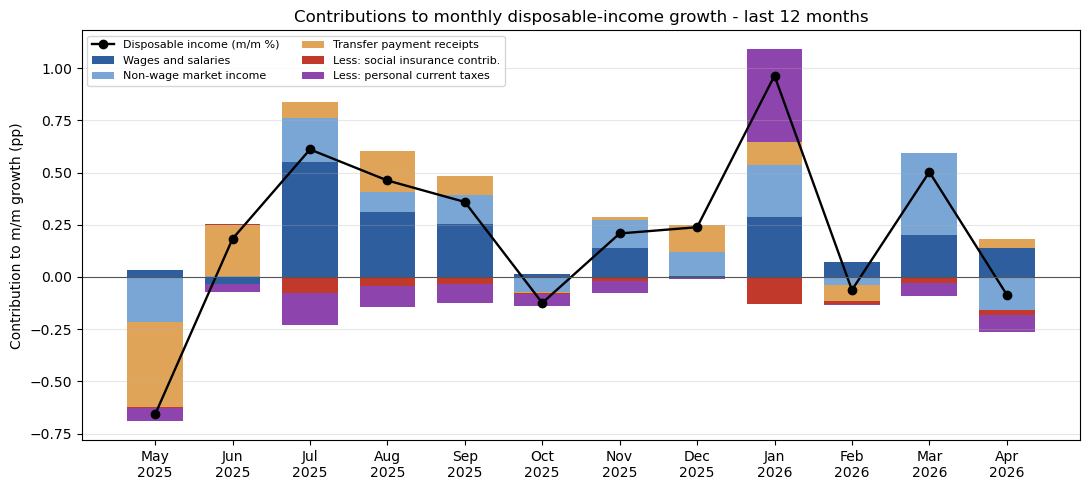

In [6]:
contrib_chart(cmm_dpi, dpi_mm, DPI_COMPS, "Disposable income",
              f"Contributions to monthly disposable-income growth - last {N_MONTHS} months",
              "pi_2_6_dpi_contributions.png")

## 6. Summary table — contributions to Personal & Disposable income

For the latest month: each component's weight (share of the total), own m/m & y/y % change, and
contribution (pp). Two blocks — one against **Personal income**, one against **Disposable income**.
Deduction lines carry negative weights and contributions.

In [7]:
NUM = ["m/m %", "y/y %", "m/m contrib (pp)", "y/y contrib (pp)"]


def build_block(comp_list, total_label, total_mm, total_yy, total_lvl, cmm_x, cyy_x):
    rows = [{"Category": total_label, "Weight (% of total)": 100.0,
             "m/m %": total_mm.loc[latest], "y/y %": total_yy.loc[latest],
             "m/m contrib (pp)": cmm_x.loc[latest].sum(), "y/y contrib (pp)": cyy_x.loc[latest].sum(),
             "_bold": True}]
    for c in comp_list:
        rows.append({"Category": "    " + c,
                     "Weight (% of total)": comp.loc[latest, c] / total_lvl.loc[latest] * 100,
                     "m/m %": mm.loc[latest, c], "y/y %": yy.loc[latest, c],
                     "m/m contrib (pp)": cmm_x.loc[latest, c], "y/y contrib (pp)": cyy_x.loc[latest, c],
                     "_bold": False})
    return pd.DataFrame(rows)


def style_block(tdf, caption):
    bold = tdf["_bold"].tolist()
    show = tdf.drop(columns="_bold")

    def bold_rows(row):
        return [f"font-weight:{'700' if bold[row.name] else '400'};"] * len(row)

    def color(s):
        return ["color:#aaa;" if pd.isna(v) else
                ("color:#0a7d2c;" if v > 0 else ("color:#c0392b;" if v < 0 else "color:#888;"))
                for v in s]

    return (show.style
            .format({"Weight (% of total)": "{:.1f}", "m/m %": "{:+.2f}", "y/y %": "{:+.2f}",
                     "m/m contrib (pp)": "{:+.3f}", "y/y contrib (pp)": "{:+.3f}"}, na_rep="-")
            .apply(bold_rows, axis=1).apply(color, subset=NUM).hide(axis="index")
            .set_caption(caption)
            .set_properties(subset=["Category"], **{"text-align": "left"})
            .set_table_styles([
                {"selector": "caption", "props": [("font-weight", "700"), ("font-size", "13px"),
                                                  ("padding", "6px"), ("caption-side", "top")]},
                {"selector": "th.col_heading", "props": [("text-align", "right")]},
                {"selector": "td", "props": [("text-align", "right"), ("padding", "2px 10px"),
                                             ("white-space", "pre")]}]))


pi_block  = build_block(PI_COMPS,  "Personal income",   pi_mm,  pi_yy,  PI,  cmm_pi,  cyy_pi)
dpi_block = build_block(DPI_COMPS, "Disposable income", dpi_mm, dpi_yy, DPI, cmm_dpi, cyy_dpi)
display(style_block(pi_block,
        f"Personal income - contributions to growth, {latest:%B %Y}  (Table 2.6, current $, SAAR)"))
display(style_block(dpi_block,
        f"Disposable income - contributions to growth, {latest:%B %Y}  (Table 2.6, current $, SAAR)"))

Category,Weight (% of total),m/m %,y/y %,m/m contrib (pp),y/y contrib (pp)
Personal income,100.0,-0.00,+2.54,-0.000,+2.538
Wages and salaries,49.8,+0.24,+3.53,+0.121,+1.740
Non-wage market income,39.0,-0.36,+1.93,-0.140,+0.757
Transfer payment receipts,19.1,+0.19,+1.93,+0.037,+0.369
Less: social insurance contrib.,-7.8,+0.24,+4.27,-0.018,-0.328


Category,Weight (% of total),m/m %,y/y %,m/m contrib (pp),y/y contrib (pp)
Disposable income,100.0,-0.08,+2.62,-0.085,+2.619
Wages and salaries,56.7,+0.24,+3.53,+0.138,+1.983
Non-wage market income,44.3,-0.36,+1.93,-0.159,+0.862
Transfer payment receipts,21.7,+0.19,+1.93,+0.042,+0.420
Less: social insurance contrib.,-8.9,+0.24,+4.27,-0.021,-0.374
Less: personal current taxes,-13.8,+0.62,+1.95,-0.085,-0.272


## 7. Export

In [8]:
def tidy(df, name):
    t = df.copy(); t.index.name = "date"
    return (t.reset_index().melt("date", var_name="component", value_name=name)
            .set_index(["date", "component"]))

hist = pd.concat([tidy(comp, "level"), tidy(mm, "mm_pct"), tidy(yy, "yy_pct"),
                  tidy(cmm_dpi, "contrib_mm_to_DPI"), tidy(cyy_dpi, "contrib_yy_to_DPI")],
                 axis=1).reset_index()
hist.to_csv(OUTDIR / "pi_2_6_full_history.csv", index=False)
print("Wrote:")
for f in ("pi_2_6_full_history.csv", "pi_2_6_momentum.png",
          "pi_2_6_pi_contributions.png", "pi_2_6_dpi_contributions.png"):
    print("  ", (OUTDIR / f).resolve())

Wrote:
   C:\Users\abour\OneDrive\Economic Research\GDP\Personal Income and Spending\outputs\pi_2_6_full_history.csv
   C:\Users\abour\OneDrive\Economic Research\GDP\Personal Income and Spending\outputs\pi_2_6_momentum.png
   C:\Users\abour\OneDrive\Economic Research\GDP\Personal Income and Spending\outputs\pi_2_6_pi_contributions.png
   C:\Users\abour\OneDrive\Economic Research\GDP\Personal Income and Spending\outputs\pi_2_6_dpi_contributions.png
